<a href="https://colab.research.google.com/github/Ataurcuet-hub/Deep_Learning_for_Computer_Vision/blob/main/Copy_of_Wound_segmentation_using_Double_Unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#############new######
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# Squeeze-and-Excite Block
def squeeze_excite_block(inputs, ratio=8):
    init = inputs
    channel_axis = -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = GlobalAveragePooling2D()(init)
    se = Reshape(se_shape)(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    x = Multiply()([init, se])
    return x

# Convolution Block
def conv_block(inputs, filters):
    x = Conv2D(filters, (3, 3), padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = squeeze_excite_block(x)
    return x

# Encoder 1 (VGG19)
def encoder1(inputs):
    skip_connections = []
    model = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)
    names = ["block1_conv2", "block2_conv2", "block3_conv4", "block4_conv4"]
    for name in names:
        skip_connections.append(model.get_layer(name).output)
    output = model.get_layer("block5_conv4").output
    return output, skip_connections

# Decoder 1
def decoder1(inputs, skip_connections):
    num_filters = [256, 128, 64, 32]
    skip_connections.reverse()
    x = inputs

    for i, f in enumerate(num_filters):
        x = UpSampling2D((2, 2), interpolation='bilinear')(x)
        x = Concatenate()([x, skip_connections[i]])
        x = conv_block(x, f)
    return x

# Encoder 2
def encoder2(inputs):
    num_filters = [32, 64, 128, 256]
    skip_connections = []
    x = inputs

    for i, f in enumerate(num_filters):
        x = conv_block(x, f)
        skip_connections.append(x)
        x = MaxPool2D((2, 2))(x)
    return x, skip_connections

# Decoder 2
def decoder2(inputs, skip_1, skip_2):
    num_filters = [256, 128, 64, 32]
    skip_2.reverse()
    x = inputs

    for i, f in enumerate(num_filters):
        x = UpSampling2D((2, 2), interpolation='bilinear')(x)
        x = Concatenate()([x, skip_1[i], skip_2[i]])
        x = conv_block(x, f)
    return x

# ASPP (Atrous Spatial Pyramid Pooling)
def ASPP(x, filter):
    shape = x.shape

    y1 = AveragePooling2D(pool_size=(shape[1], shape[2]))(x)
    y1 = Conv2D(filter, 1, padding="same")(y1)
    y1 = BatchNormalization()(y1)
    y1 = Activation("relu")(y1)
    y1 = UpSampling2D((shape[1], shape[2]), interpolation='bilinear')(y1)

    y2 = Conv2D(filter, 1, dilation_rate=1, padding="same", use_bias=False)(x)
    y2 = BatchNormalization()(y2)
    y2 = Activation("relu")(y2)

    y3 = Conv2D(filter, 3, dilation_rate=6, padding="same", use_bias=False)(x)
    y3 = BatchNormalization()(y3)
    y3 = Activation("relu")(y3)

    y4 = Conv2D(filter, 3, dilation_rate=12, padding="same", use_bias=False)(x)
    y4 = BatchNormalization()(y4)
    y4 = Activation("relu")(y4)

    y5 = Conv2D(filter, 3, dilation_rate=18, padding="same", use_bias=False)(x)
    y5 = BatchNormalization()(y5)
    y5 = Activation("relu")(y5)

    y = Concatenate()([y1, y2, y3, y4, y5])
    y = Conv2D(filter, 1, dilation_rate=1, padding="same", use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation("relu")(y)

    return y

# Output Block
def output_block(inputs):
    x = Conv2D(1, (1, 1), padding="same")(inputs)
    x = Activation('sigmoid')(x)
    return x

# Build Model
def build_model():
    size = 256
    inputs = Input((size, size, 3))

    x, skip_1 = encoder1(inputs)
    x = ASPP(x, 64)
    x = decoder1(x, skip_1)
    outputs1 = output_block(x)

    x = inputs * outputs1
    x, skip_2 = encoder2(x)
    x = ASPP(x, 64)
    x = decoder2(x, skip_1, skip_2)
    outputs2 = output_block(x)

    outputs = Concatenate()([outputs1, outputs2])
    model = Model(inputs, outputs)
    return model





In [ ]:
# Metrics and Loss
def dice_coefficient(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def iou_score(y_true, y_pred):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1, 2, 3])
    union = K.sum(y_true, axis=[1, 2, 3]) + K.sum(y_pred, axis=[1, 2, 3]) - intersection
    return K.mean((intersection + 1e-7) / (union + 1e-7), axis=0)

def f1_score(y_true, y_pred):
    y_pred_binary = tf.round(y_pred)
    true_positives = K.sum(y_true * y_pred_binary)
    possible_positives = K.sum(y_true)
    predicted_positives = K.sum(y_pred_binary)
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, TensorBoard, EarlyStopping
from tensorflow.keras.optimizers import Adam
from glob import glob

# Define custom loss and metrics
def dice_loss(y_true, y_pred):
    numerator = 2 * tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    return 1 - numerator / (denominator + tf.keras.backend.epsilon())

def dice_coef(y_true, y_pred):
    numerator = 2 * tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    return numerator / (denominator + tf.keras.backend.epsilon())

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    return intersection / (union + tf.keras.backend.epsilon())

# Read and preprocess images
def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (256, 256))
    x = x.astype(np.float32)
    x = x / 255.0
    return x

def read_mask(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (256, 256))
    x = x.astype(np.float32)
    x = x / 255.0
    x = np.expand_dims(x, axis=-1)  # Add channel dimension
    return x

# Preprocess and load data
def preprocess_data(x, y):
    x = read_image(x)
    y = read_mask(y)
    y = np.concatenate([1 - y, y], axis=-1)  # Binary representation
    return x, y

def load_data(train_path, valid_path):
    train_x = sorted(glob(os.path.join(train_path, "images", "*.png")))
    train_y = sorted(glob(os.path.join(train_path, "labels", "*.png")))
    valid_x = sorted(glob(os.path.join(valid_path, "images", "*.png")))
    valid_y = sorted(glob(os.path.join(valid_path, "labels", "*.png")))

    train_data = [preprocess_data(x, y) for x, y in zip(train_x, train_y)]
    valid_data = [preprocess_data(x, y) for x, y in zip(valid_x, valid_y)]
    return train_data, valid_data

if __name__ == "__main__":
    # Paths
    train_path = "/content/drive/MyDrive/Foot Ulcer Segmentation Challenge/train"
    valid_path = "/content/drive/MyDrive/Foot Ulcer Segmentation Challenge/validation"
    model_path = "/content/drive/MyDrive/WOUND SEGMENTATION/model.h5"

    # Hyperparameters
    batch_size = 10
    epochs = 20
    lr = 1e-4

    # Define model (replace with your actual model definition)
    model = build_model()

    # Define metrics
    metrics = [
        iou,
        dice_coef
        ]

    # Load data
    train_data, valid_data = load_data(train_path, valid_path)
    train_x, train_y = zip(*train_data)
    valid_x, valid_y = zip(*valid_data)


    train_dataset = tf.data.Dataset.from_generator(lambda: train_data,
                                              output_signature=(tf.TensorSpec(shape=(256, 256, 3), dtype=tf.float32),
                                                                tf.TensorSpec(shape=(256, 256, 2), dtype=tf.float32)))

    train_dataset = train_dataset.batch(batch_size)

    valid_dataset = tf.data.Dataset.from_generator(lambda: valid_data,
                                              output_signature=(tf.TensorSpec(shape=(256, 256, 3), dtype=tf.float32),
                                                                tf.TensorSpec(shape=(256, 256, 2), dtype=tf.float32)))

    valid_dataset = valid_dataset.batch(batch_size)



In [ ]:
    # Compile model
    model.compile(
        loss=dice_loss,
        optimizer=Adam(lr),
        metrics=metrics
    )

    # # Callbacks
    callbacks = [
    ModelCheckpoint(model_path.replace('.h5', '.keras'), save_best_only=True),  # Change to .keras
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=int(epochs * 0.3)),
    TensorBoard(),
    EarlyStopping(monitor='val_loss', patience=int(epochs * 0.3), restore_best_weights=True)
    ]


    # Train model
    train_steps = len(train_x) // batch_size
    valid_steps = len(valid_x) // batch_size
    train_dataset = train_dataset.repeat()

    model.fit(
        train_dataset,
        validation_data=valid_dataset,
        steps_per_epoch=train_steps,
        validation_steps=valid_steps,
        epochs=epochs,
        callbacks=callbacks
    )


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 124s 901ms/step - dice_coef: 0.8618 - iou: 0.7574 - loss: 0.1382 - precision_1: 0.9904 - recall_1: 0.9940 - val_dice_coef: 0.8520 - val_iou: 0.7423 - val_loss: 0.1480 - val_precision_1: 0.9916 - val_recall_1: 0.9930 - learning_rate: 1.0000e-04
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 60s 742ms/step - dice_coef: 0.8737 - iou: 0.7761 - loss: 0.1263 - precision_1: 0.9908 - recall_1: 0.9948 - learning_rate: 1.0000e-04
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 833ms/step - dice_coef: 0.8845 - iou: 0.7933 - loss: 0.1155 - precision_1: 0.9923 - recall_1: 0.9945 - val_dice_coef: 0.8782 - val_iou: 0.7829 - val_loss: 0.1218 - val_precision_1: 0.9916 - val_recall_1: 0.9930 - learning_rate: 1.0000e-04
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 60s 740ms/step - dice_coef: 0.8947 - iou: 0.8098 - loss: 0.1053 - precision_1: 0.9929 - recall_1: 0.9944 - learning_rate: 1.0000e-04
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 843ms/step - dice_coef: 0.9055 - iou: 0.8276 - loss: 

In [ ]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('/content/drive/MyDrive/WOUND SEGMENTATION/model.keras',
                   custom_objects={'dice_loss': dice_loss, 'iou': iou, 'dice_coef': dice_coef})

NameError: name 'dice_loss' is not defined

In [ ]:
import os
import cv2
import numpy as np
from glob import glob

def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (256, 256))
    x = x.astype(np.float32)
    x = x / 255.0
    return x

# Assuming you have a 'test' folder with only images
test_path = "/content/drive/MyDrive/Foot Ulcer Segmentation Challenge/test"
test_x = sorted(glob(os.path.join(test_path, "images", "*.png")))
test_images = [read_image(x) for x in test_x]

In [ ]:
predictions = model.predict(np.array(test_images))

7/7 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step


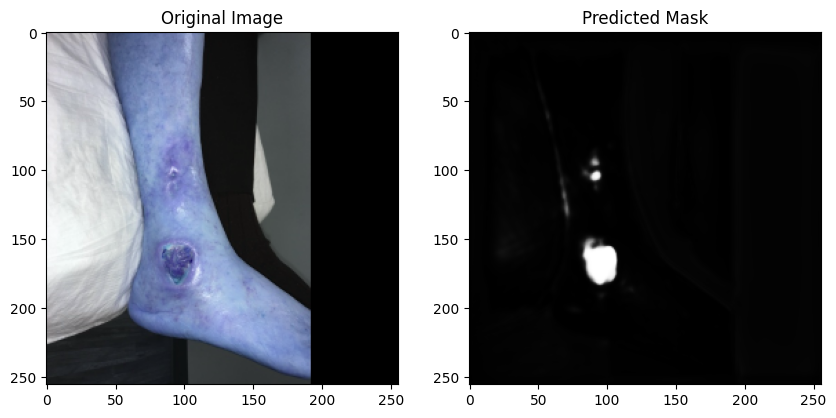

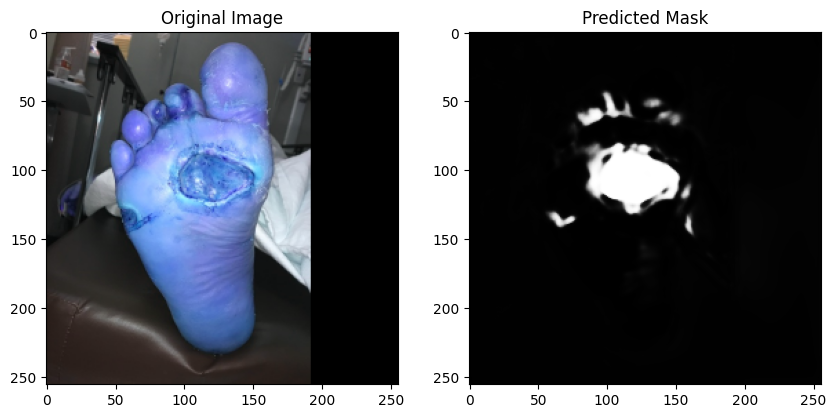

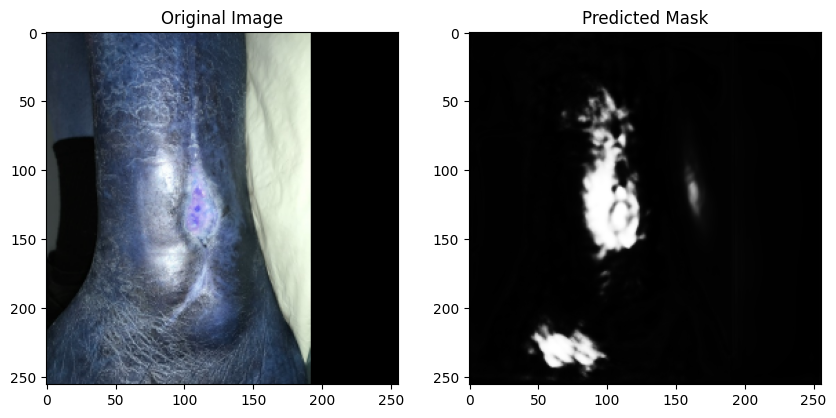

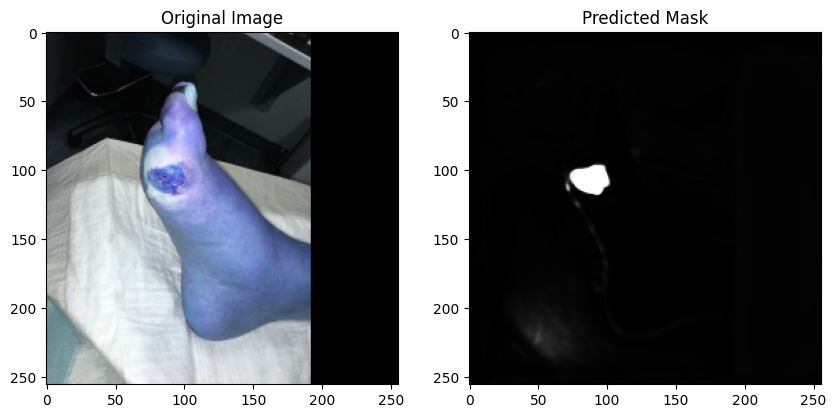

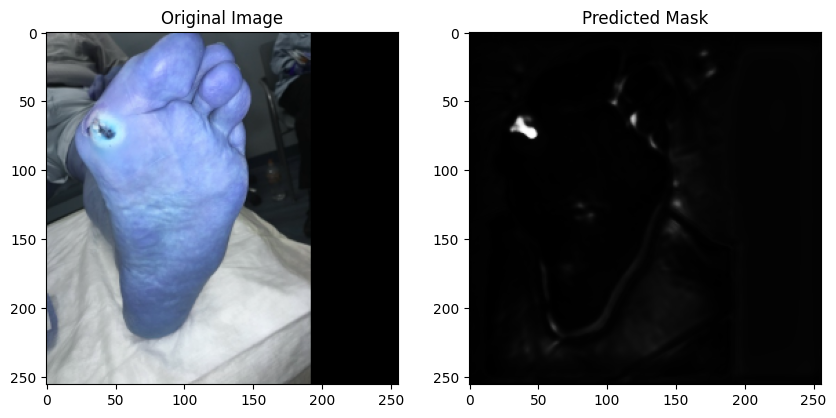

In [ ]:
import matplotlib.pyplot as plt

def display_predictions(images, predictions, num_images=5):
    for i in range(num_images):
        plt.figure(figsize=(10, 5))

        # Display original image
        plt.subplot(1, 2, 1)
        plt.imshow(images[i])
        plt.title("Original Image")

        # Display predicted mask
        plt.subplot(1, 2, 2)
        plt.imshow(predictions[i, :, :, 1], cmap='gray')  # Assuming binary segmentation (class 1 is the wound)
        plt.title("Predicted Mask")

        plt.show()

# Display predictions for a few images
display_predictions(test_images, predictions)